# Illustration of extended PINN Problems

In [1]:
import os
# Surpress unnecessary output from tensorflow package
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Change the working dorectory, for easier imports and running
os.chdir(os.path.dirname(os.path.abspath('../pyproject.toml')))

# Import necessary functions/ packages
from Utils.plot import simp_plot, plot_err_vs_epoch, mult_2D_plot
from PINNLearning.data import set_boundaries, add_noise, alph_sim, gen_data
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

We first need to set some global values and settings:

In [2]:
# Plot settings
plt.close('all')
plt.rcParams['font.size'] = 10

# Dimensions of the simulation space
lower_bound = 0.0
upper_bound = 1.0

## Inverse Problem

We are addressing the so-called **inverse problem**. Here, the objective is not only to _identify the described equation_ but also to simultaneously determine the _unknown parameters_ of the differential equation itself. To illustrate this, we will again consider the modified, one-dimensional heat equation in a normalized problem space:

$$u(x) = \dfrac{d}{dx} \left[ \alpha(x) \cdot \dfrac{d}{dx} u(x) \right]$$

As the boundary conditions, we impose the Dirichlet conditions form before:

$u(0) = 1$ and $u(1) = 0$

In this formulation, we take the diffusivity $\alpha(x)$ as _undefined_. This allows the modeling of differential equations that are known, while specific parameters remain unknown. Utilizing PINNs, it becomes feasible to learn not only the underlying function $u(x)$ but also the missing parameter $\alpha(x)$. The DeepXDE framework, discussed in the previous section of the notebook titled `2D & time dependent`, facilitates this process.

Given that some information from the problem is missing, it must be supplemented with additional data in the form of **measurement points** of the function we aim to approximate. This approach is effective whether $\alpha(x)$ is a _constant value_ or a _spatially varying function_.

To obtain this data, the simulations for varying material conditions from the last problem in the `1D & time independent` notebook are used. Additionally noise will be introduced to create a more realistic dataset. The additional data will be treated similarly to the author’s approach, entered as Dirichlet conditions.

In [3]:
# Set alpha as a constant value
def alph_const(x):
    return 0.1  # small value ensures curvature

# Set tha alpha as a inverted sigmoid funciton with k=7
def alph_func(x):
    return 1 / (1 + np.exp(7 * (x - 0.5)))

# Draw both for visual comparison
x_data = gen_data(0, 1, 100)
# Set the boundary conditions
_, y_bc = set_boundaries([[0.0], [1.0]], [[1.0], [0.0]])

# Ideal data for comparison
y_true_alph_const = alph_sim(x_data, y_bc, alph_const)
y_true_alph_func = alph_sim(x_data, y_bc, alph_func)

# Noisy measurements
y_noisy_alph_const = add_noise(y_true_alph_const, 0.2)
y_noisy_alph_func = add_noise(y_true_alph_func, 0.2)

### Simplified Case with Constant Diffusivity

In the simpler case where $\alpha(x)=const$, the equation we aim to identify can be expressed as:

$u(x)= \alpha \cdot \dfrac{d^2 u(x)}{d x^2}$

​
In this formulation, we define $\alpha(x)$ as a variable and proceed to formulate the problem in the same manner as before.


It is crucial to note that $\alpha$ appears **here** in the term with the second derivative. If the value of that derivative _approaches zero_ (the function we are attempting to approximate is linear), it hinders the updating process of $\alpha$. For the learning algorithm to effectively update this value, the underlying function _must_ exhibit **curvature**, otherwise, the model will fail to capture the necessary dynamics of the system.

This **dependency on the structure of the differential** equation is _significant_. Thus, careful consideration of the underlying function’s characteristics is essential for successful parameter identification. This is a general concern for such inverse problems.

In [4]:
# Import deepXDE AFTER using Tf 2
import deepxde as dde

# Define alpha as a trainable variable with an initial guess of 1.0
alpha = dde.Variable(1.0)

# The PDE now uses the trainable variable 'alpha'
def heat_equation_const(x, u):
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    return u - alpha * u_xx

# Definition of the geometry
x_domain = dde.geometry.Interval(lower_bound, upper_bound)

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
# Create a Dirichlet boundary condition from the "measured" data points
observation_data = dde.icbc.PointSetBC(
    x_data,                              # x-points in space
    y_noisy_alph_const,                  # values at the points
    component=0                          # which output from the PINN needs to satisfy this
)

# Create the Dirichlet boundary conditions on x-domain
x_bc = dde.icbc.DirichletBC(
    x_domain,
    lambda bps: 1 - bps[:],
    lambda _, on_boundary: on_boundary,
    component=0
)

Compiling model...
Building feed-forward neural network...
'build' took 0.091440 s

'compile' took 0.574241 s

INFO:tensorflow:Restoring parameters from ./data/sp_inverse_simp/inverse_simp-2000.ckpt
Compare the values for the alpha constant:
     Inferred Alpha                    Simulated Alpha
       0.09752623                            0.1


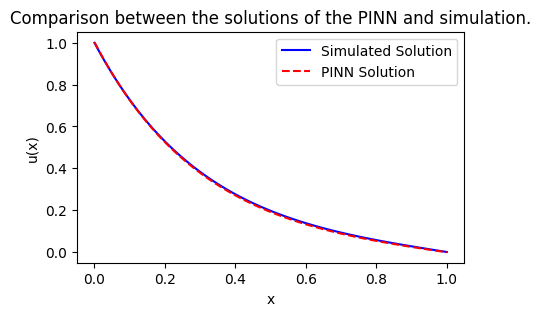

In [6]:
# Create the data object now including the observation data
data = dde.data.PDE(
    x_domain,
    heat_equation_const,
    [x_bc, observation_data],
    num_domain=2540,
    num_boundary=80,
    num_test=2540
)

# Create the neural network
net = dde.nn.FNN([1] + [50] * 3 + [1],
                "tanh",
                "Glorot uniform",
                regularization=["l2", 1e-4]
)
model = dde.Model(data, net)
model.loss_weights = [200, 100, 50, 1]  # [inner, bc, points, reg]
# FYI: Alpha is part of the pde (inner) loss term as such the attention
# for training must lie here. The large weight scalar values force the
# trainer to go through more steps for convergence.

# Inform the compiler about the trainable variable
model.compile(
    "adam",
    lr=1e-3,
    external_trainable_variables=[alpha]
)

# Check the progress of alpha
var_callback = dde.callbacks.VariableValue(
    [alpha],
    period=200
)

# Train the model if it is not already trained
if os.path.exists('./data/sp_inverse_simp/inverse_simp-2000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model.restore('./data/sp_inverse_simp/inverse_simp-2000.ckpt')
else:
    losshistory, train_state = model.train(
        iterations=2000,
        display_every=200,
        callbacks=[var_callback]
    )
    model.save("./data/sp_inverse_simp/inverse_simp")

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

# Comapare the Value of alpha
print("Compare the values for the alpha constant:")
print(5*" " + "Inferred Alpha" + 20*" " + "Simulated Alpha")
print(7*" " +  f"{model.sess.run(alpha):.8f}" + 28*" " + f"{alph_const(0)}")

# Visualy compare the PINN with the simulation
x_points = x_domain.uniform_points(100)
y_pred = model.predict(x_points)

data = [
    [x_data.numpy(), y_true_alph_const, 'b-', ('label', 'Simulated Solution')],
    [x_points, y_pred, 'r--', ('label', 'PINN Solution')]
]
plt = simp_plot(data, 'Comparison between the solutions of the PINN and simulation.', ylabel='u(x)')
plt.show()

The model demonstrates a satisfactory fit to the noisy data and effectively predicts $u(x)$.
The parameter $\alpha$ was accurately estimated, although it is important to acknowledge that this value is subject to error. When rounded to an appropriate number of decimal places, the apparent error may seem negligible. However, in the context of an entirely unknown problem, determining the "correct" number of decimal places remains ambiguous, presenting a significant consideration in the analysis.

### Complex Case with Spatially Varying Diffusivity

In the more complex scenario where $\alpha(x)$ is defined as a _function_ rather than a constant, it cannot simply be treated as a variable. Instead, $\alpha(x)$ must be represented as a **neural network** itself. This approach allows for the modeling of spatially varying diffusivity, which can capture more intricate behaviors of the system.
However, since the model object of DeepXDE is designed to work with a single model, the representation of the diffusivity must be integrated into the _same_ neural network that approximates $u(x)$. This integration is very _challenging_, as it requires the neural network to simultaneously learn both the underlying function and the spatially varying parameter which might have conflicting gradients or operate on different scales.


In many cases, there are **NO** explicit boundary or initial conditions for the function $\alpha(x)$. This flexibility means that $\alpha(x)$ can be represented as **ANY** function that is describable by the chosen neural network architecture. While it is generally _not strictly necessary_ to provide these conditions, as the problem is sufficiently defined by the conditions and additional data for $u(x)$, incorporating prior knowledge about $\alpha(x)$ can significantly enhance the model’s performance and even be a requirement for convergence. This prior knowledge can include a **smoothness regularization term** that penalizes the gradient of $\alpha(x)$, **constraints** such as positivity or boundedness, or even an **informative initial guess**.


For the problem at hand, as we are examining the diffusivity of a material, we can be confident that this function will always be _positive_. Additionally, since we are operating in a normalized space, the function will never exceed a _value of one_. These limits can be enforced by applying a **clipping function** as an output transformation (hard constraint) to the utilized FNN architecture. However, this clipping function introduces certain obvious challenges that must be addressed through pre-training (warm starting) the model.
Furthermore, based on the sampled data, we can infer that the function should exhibit larger values for $x$ close to $0$ and lower values as $x$ approaches $1$, with smooth transitions. Therefore, we can propose an _initial guess_ for this function in the following form:

$ \alpha_{prior}(x) = \frac{1}{2} \cdot (\cos(\pi \cdot x) + 1)$


Such an initial guess is imposed as an additional loss term for the trainer to optimize. To further assist the model in converging to the proper solutions, three modifications were made to the setup from the previous example:

- The boundary conditions of $u(x)$ are included as **hard conditions** (as output transformations instead of loss terms). This approach forces the output of the model to yield the correct values, providing a much stronger condition that facilitates quicker convergence.

- The differential equation is reformulated as a **system of two first-order equations**:
    $\begin{align}
        u(x) &= \dfrac{d}{dx} v(x) \\
        v(x) &= a(x) \cdot \dfrac{d}{dx} u(x)
    \end{align}$
    This change eliminates the second-order automated derivatives from the framework, reducing the error in the system since that derivative is more error-prone than the first-order derivatives.

- A **curriculum learning** regime was adopted. This concept describes the learning process in a progressive manner, where a problem is modified in multiple steps (phases) from an initial to a final (originally intended) problem. This approach allows the model to first learn a specific (typically simplified) representation of the problem and then refine that solution towards the actual one as the learning phases progress. In this case, curriculum learning was employed to address the challenges introduced by the clipping function for the output of $\alpha(x)$, warm starting the whole training process. The following initial learning focused on $u(x)$ based on its sample data, and subsequently, the solution of $u(x)$ was refined to accurately determine the correct $\alpha(x)$.


In [16]:
# Define the PDE with the input u containing both
# the two 1D equations and alpha
def heat_equation_func(x, u):
    u_val, v_val, alpha = u[:, 0:1], u[:, 1:2], u[:, 2:3]

    # derivatives of the individual parts
    u_x = dde.grad.jacobian(u, x, i=0, j=0)
    v_x = dde.grad.jacobian(u, x, i=1, j=0)
    # assamble the two equations
    eq1 = v_x - u_val
    eq2 = v_val - alpha * u_x
    return [eq1, eq2]

# Update the Dirichlet condition of the "measured" data points
observation_data = dde.icbc.PointSetBC(
    x_data,
    y_true_alph_func,
    component=0  # here setting this correctly is immperative!
                 # --> should only be ative for u(x)
)

In [ ]:
# Introduce a variable to controle the initial two training phases
phase = tf.Variable(1, trainable=False)
# FYI: Must be a tf.Variable as only this way it gets included in the 
# network graph (thus it will be automatically saved and restored by
# DeepXDE), without being trainable.

# Create the transformation for the output of the FNN
def transform_output(x, y):
    # split the output of the model
    u_raw, v, alpha_raw = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    # enforce the boundaries as hard boundary conditions
    u = (1 - x) + x * (1 - x) * u_raw
    # switch between the initializer that forces alpha to be in (0,1)
    # and the hard constraint depending on the training phase
    alpha = tf.cond(tf.equal(phase, 1),
                    lambda: tf.sigmoid(alpha_raw - 0.5),
                    lambda: tf.clip_by_value(alpha_raw, 0, 1)
    )
    # combine all outputs to match the normal model output
    return tf.concat([u, v, alpha], axis=1)

# Calculate the residual of the soft constraint based on the intial
# guess for alpha
def alpha_res(x, u, X):
    cos = 0.5 * (tf.math.cos(tf.constant(np.pi) * x) + 1) + 1e-6
    # add 1e-6 for numerical stability
    return u[:, 2:3] - cos

# Introduce the initial guess as condition for the optimizer
alpha_prior = dde.icbc.OperatorBC(
    x_domain,
    alpha_res, # The operator function 
    lambda _, on_boundary: not on_boundary  # active only on the inside
)
# FYI: Unlike in the other definitions, here the value of the boundary
# is encoded into the operator function. This function takes a set of 
# input points, the corresponding output of the network and a numpy list
# of the coordinates of the input points. It returns the RESIDUAL
# instead of the actual value of the boundary condition!

Compiling model...
Building feed-forward neural network...
'build' took 0.121126 s

'compile' took 1.052253 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [2.12e+00, 1.68e+01, 1.26e+01, 1.37e-01, 2.02e-02]    [2.09e+00, 1.69e+01, 1.26e+01, 1.37e-01, 2.02e-02]    []  
500       [6.59e-03, 1.81e-03, 1.24e-02, 3.46e-03, 2.17e-02]    [5.29e-03, 1.73e-03, 1.24e-02, 3.46e-03, 2.17e-02]    []  

Best model at step 500:
  train loss: 4.59e-02
  test loss: 4.45e-02
  test metric: []

'train' took 16.061685 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
500       [6.59e-03, 2.37e+00, 1.24e-02, 4.03e-02, 2.17e-02]    [5.29e-03, 2.40e+00, 1.24e-02, 4.03e-02, 2.17e-02]    []  
600       [6.47e-02, 1.64e-01, 1.45e-01, 1.62e-03, 2.13e-02]    [5.85e-02, 1.66e-01, 1.45e-01, 1.62e-03, 2.

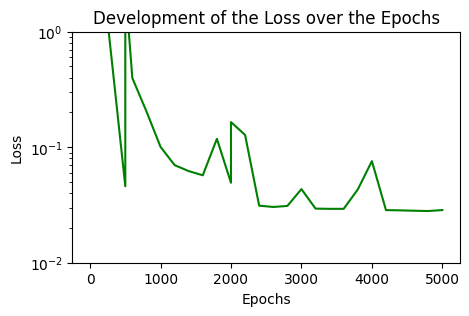

In [ ]:
# Create the data objects now including the observation data
# and the prior
data = dde.data.PDE(
    x_domain,
    heat_equation_func,
    [observation_data, alpha_prior],
    num_domain=3500,
    num_boundary=80,
    num_test=3500
)

# Define the nerual network
net = dde.nn.FNN([1] + [50] * 5 + [3],  # output = u(x), v(x), alpha(x)
               "tanh",
               "Glorot uniform",
               regularization=["l2", 1e-4]
)
# Apply the output transformation
net.apply_output_transform(transform_output)
model2 = dde.Model(data, net)
model2.compile("adam", lr=1e-3, loss_weights=[10, 100, 500, 1, 1])  # [eq1, eq2, points, prior, reg]
# FYI: As alpha is included in the equations and there are an 
# theoretically infinit amount of solutions for alpha, we must force
# the training to converge to OUR specific solution. Thus the emphasis
# for training must be placed on the points term.

# Train the model if it is not already trained
if os.path.exists('./data/sp_inverse_func/inverse_func-5000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model2.restore('./data/sp_inverse_func/inverse_func-5000.ckpt')
else:
    # In the first phase set up training and start initialization of the network
    losshistory, train_state = model2.train(500)
    # FYI: Important as the hard constraints on alpha are reinforced using a clip function.
    # If not done, the network might randomly be initialized with alpha below 0 and
    # thus destroying all gradients. NO update to the weights would happen.

    # Switch to the second training phase, for this "turn off" the initializer transform on 
    # alpha by using the variable "inside" of the model
    model2.sess.run(phase.assign(2))
    # Train second phase with activated hard constraints and lower weight for the alpha_prior
    model2.train(1500, display_every=200)
    # FYI: Initially prioritize the learning of the u(x) instead of the a(x).

    # Train third phase with larger weight for alpha_prior
    model2.compile("adam", lr=1e-3, loss_weights=[10, 100, 500, 10, 1])
    model2.train(3000, display_every=200)
    # FYI: After u(x) is good enough, try to find a(x) that fits and improves u(x)
    # correspondingly.

    model2.save("./data/sp_inverse_func/inverse_func")

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

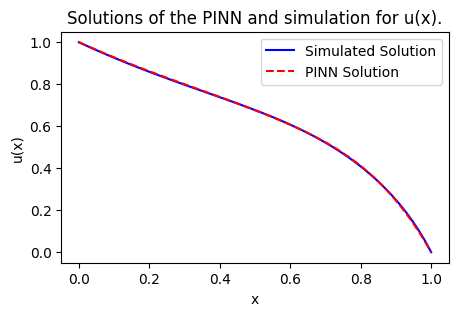

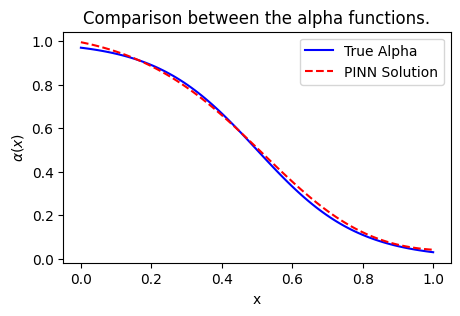

In [ ]:
# Visualy compare the PINN with the simulation and the true alpha
x_points = x_domain.uniform_points(100)
y_pred = model2.predict(x_points)
alpha_points = alph_func(x_points)

# Compare the u(x)
data = [
    [x_data.numpy(), y_true_alph_func, 'b-', ('label', 'Simulated Solution')],
    [x_points, y_pred[:, 0:1], 'r--', ('label', 'PINN Solution')]
]
plt = simp_plot(data, 'Solutions of the PINN and simulation for u(x).', ylabel='u(x)')
plt.show()

# Compare the a(x)
data = [
    [x_data.numpy(), alpha_points, 'b-', ('label', 'True Alpha')],
    [x_points, y_pred[:, 2:3], 'r--', ('label', 'PINN Solution')]
]
plt = simp_plot(data, 'Comparison between the alpha functions.', ylabel=r'$\alpha(x)$')
plt.show()

When addressing this problem, it becomes evident that the correct solution for $u(x)$ is readily obtained. The results demonstrate a strong alignment with the expected solution.
In contrast, the estimation of $\alpha(x)$ presents a more complex challenge. Achieving convergence of the model towards the true solution is notably difficult, and the results indicate that the solution still exhibits some errors. This discrepancy likely arises from the initial guess for $\alpha(x)$, which may not fully represent the actual function. While increasing the number of training epochs could potentially improve the model’s performance, it remains uncertain whether this approach will definitively resolve the issue.

Consequently, it is crucial to account for the (potentially significant) errors in the prediction of the unknown value and to carefully consider the challenges associated with training in this context.

## Learning various Boundary Conditions

In this series of notebooks, we have demonstrated the feasibility of learning the solution to a differential equation given specific boundary and initial conditions. This raises an important question: **is it possible to not only learn a single solution to the equation but also to learn all possible solutions?**

Such problems are typically classified as **parameterized problems**. They are generally addressed using _one or a combination_ of the following two methodologies:
- Parameterized Physics-Informed Neural Networks (P-PINNs)
- Meta-Learning or Transfer Learning


While other methods exist, these two are the most frequently discussed in the literature. The first approach, incorporates additional parameters (such as boundary conditions and potentially other factors like the diffusivity in this case) as input variables into the neural network. By significantly expanding the dimensions of the neural network, it becomes possible to learn the mapping from these parameters to the corresponding solutions.
The second approach emphasizes rapid adaptation of a pre-trained model to new conditions. For a more comprehensive understanding of these topics, refer to the paper by [Cho W. et al., 2024](https://arxiv.org/abs/2408.09446v1).

For this problem, we return to the following initial problem in the notebook `1D & time independent` and discuss the parameterized approach:

$$u(x) = \alpha \cdot \dfrac{d^2}{dx^2} u(x)$$

The problem is again normalized over the range $[0,1]$, with $\alpha = 1$ and the Dirichlet boundary conditions specified as:

$u(0) = u_0$ and $u(1) = u_1$

In this context, the set of possible values for both conditions encompasses _all numbers_ within the range $[0,1]$ and _any conceivable combination_ of these values. The framework is established similarly to previous implementations, with the key difference being that the boundary conditions are _included as inputs_ to the network. Additionally, the depth of the network is significantly increased. Although this increase exceeds what is strictly necessary, it substantially _enhances_ the predictive performance of the model.

In [6]:
# Define the simplified heat equation from before
def simp_heat_equation(x, u):
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    return u - u_xx

# Use a hypercube to represent the combined input space of (x, u_0, u_1).
domain = dde.geometry.Hypercube(xmin=[lower_bound]*3, xmax=[upper_bound]*3)

# Calculate the residual for the left BC: u(0) - u_0 = 0.
def bc_op_left(x, u, X):
    return u - x[:, 1:2]

# Create the OperatorBC for the left boundary
bc_left = dde.icbc.OperatorBC(
    domain,
    bc_op_left,
    lambda bp, on_boundary:
        on_boundary and np.isclose(bp[0], lower_bound)
)

# Calculate the residual for the right BC: u(1) - u_1 = 0.
def bc_op_right(x, u, X):
    return u - x[:, 2:3]

# Create the OperatorBC for the right boundary
bc_right = dde.icbc.OperatorBC(
    domain,
    bc_op_right,
    lambda bp, on_boundary:
        on_boundary and np.isclose(bp[0], upper_bound)
)

In [7]:
# Comnine everythin into the data object
data = dde.data.PDE(
    domain,
    simp_heat_equation,
    [bc_left, bc_right],
    num_domain=3500,
    num_boundary=1000,
    num_test=3500
)

# The network takes 3 inputs (x, u0, u1)
net = dde.nn.FNN([3] + [50] * 10 + [1],
                "tanh",
                "Glorot uniform",
                regularization=["l2", 1e-4]
)
model3 = dde.Model(data, net)
model3.compile("adam", lr=1e-3)

# Train the model if it is not already trained
if os.path.exists('./data/sp_multi_bc/multi_bc-4000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model3.restore('./data/sp_multi_bc/multi_bc-4000.ckpt')
else:
    losshistory, train_state = model3.train(
        iterations=4000,
        display_every=500
    )
    model3.save("./data/sp_multi_bc/multi_bc")

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

Compiling model...
Building feed-forward neural network...
'build' took 0.168525 s

'compile' took 0.952552 s

INFO:tensorflow:Restoring parameters from ./data/sp_multi_bc/multi_bc-4000.ckpt


As illustrated below, we compare the predictions for the randomly sampled boundary conditions with the analytical solution given by:

$u(x, u_0, u_1) = \dfrac{u_0 \cdot (e^{1-x}-e^{x - 1}) + u_1 \cdot (e^{x}-e^{-x})}{e^{1}-e^{-1}}$

This analytical solution was derived in the same manner as in the initial instance of this problem, utilizing the general Dirichlet boundary conditions specified earlier.


The results indicate that, in the majority of cases, the predictions generated by the PINN align closely with the corresponding analytical solutions. This demonstrates that a PINN **can be effectively extended to capture the entirety of the problem** rather than merely a subset of it. Given that inference on an AI model is _significantly more efficient_ than traditional simulation or retraining methods, it can be advantageous to allocate additional resources towards training this larger model.
However, it is important to note that this approach is mainly applicable to _relatively_ simple equations. While it theoretically extends to more complex equations, the size of the neural network increases substantially, complicating the problem.

In the context of varying initial conditions, research conducted in the master’s thesis by [Schäfer V., 2022](https://elib.dlr.de/185457/1/master_thesis.pdf) has shown that these conditions demonstrate difficulties when modeled in the same manner. Instead, they necessitate the application of more advanced meta-learning techniques.

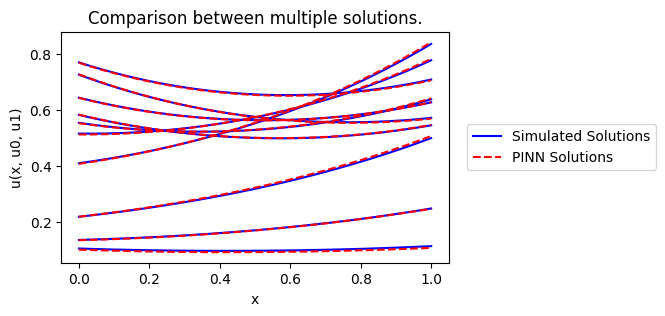

In [8]:
# Visualy compare the PINN with the simulation

# Define the analytical solution depending on the provided
# boundary conditions of the diff. eq.
def analytical_solution(x, u0, u1):
    denom = np.exp(1) - np.exp(-1)
    num_left = u0 * (np.exp(1-x) - np.exp(x-1))
    num_right = u1 * (np.exp(x) - np.exp(-x))
    return (num_left + num_right)/denom

# Create the array of point coordinates
x_points = np.linspace(lower_bound, upper_bound, 1000)
u0_points = np.random.uniform(lower_bound, upper_bound, (10, 1))
u1_points = np.random.uniform(lower_bound, upper_bound, (10, 1))

# Initialize empty lists to store the resulting arrays
y_sim = []
y_pred = []
# Loop through each of the 10 pairs of u0 and u1 values
for i in range(len(u0_points)):
    # Select the i-th value from u0_points and u1_points
    u0_current = u0_points[i]
    u1_current = u1_points[i]

    # Repeat the current u0 and u1 values to match the length of x_points
    u0_repeated = np.repeat(u0_current, len(x_points))
    u1_repeated = np.repeat(u1_current, len(x_points))
    # Create a single array with 1000 rows and 3 columns
    combined_vector = np.column_stack((x_points, u0_repeated, u1_repeated))
    # Add the resulting arrays to the lists
    y_sim.append(analytical_solution(x_points, u0_current, u1_current))
    y_pred.append(model3.predict(combined_vector))

data = [
    [x_points, y_sim, 'b-', ('label', 'Simulated Solutions')],
    [x_points, y_pred, 'r--', ('label', 'PINN Solutions')]
]
plt = mult_2D_plot(data, 'Comparison between multiple solutions.', ylabel='u(x, u0, u1)')
plt.show()

## Neural Operators